<a href="https://colab.research.google.com/github/Bassendiaye/mes_notebooks/blob/main/Analyse_du_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyse du Dataset avant utilisation**

In [ ]:
!pip install albumentations torchvision opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import matplotlib.pyplot as plt

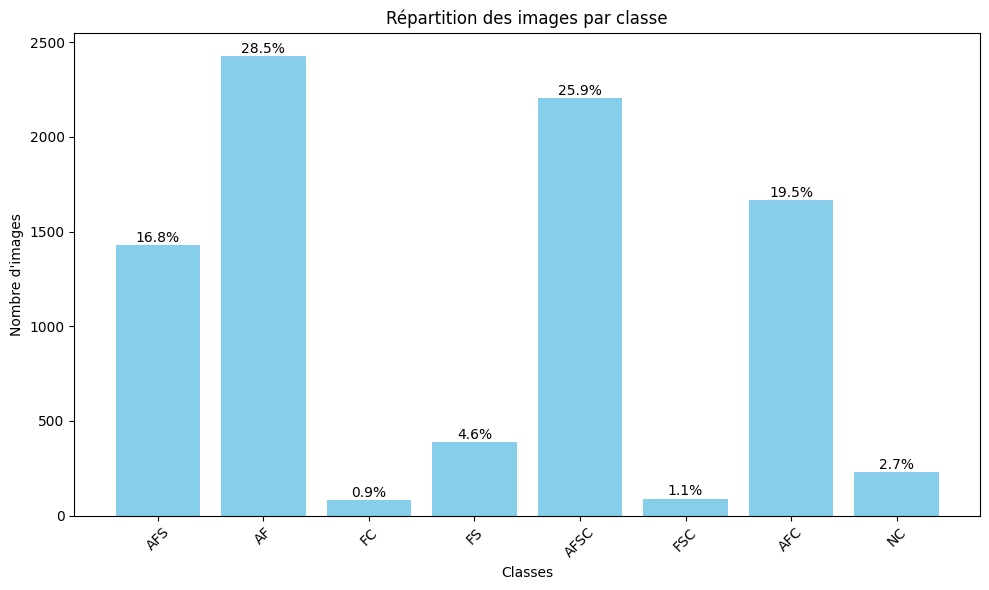

In [ ]:
# Chemin du dossier principal
dossier_principal = "/content/drive/MyDrive/Data_paper2_bis"

# Dictionnaire pour stocker le nombre d'images par classe
repartition = {}

# Extensions d'images
extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

# Comptage des images
for nom_classe in os.listdir(dossier_principal):
    chemin_classe = os.path.join(dossier_principal, nom_classe)
    if os.path.isdir(chemin_classe):
        nb_images = len([f for f in os.listdir(chemin_classe) if f.lower().endswith(extensions)])
        repartition[nom_classe] = nb_images

# Calcul des pourcentages
total_images = sum(repartition.values())
repartition_pourcentages = {classe: (nb / total_images) * 100 for classe, nb in repartition.items()}

# -------- GRAPHE À BARRES --------
plt.figure(figsize=(10, 6))
bars = plt.bar(repartition.keys(), repartition.values(), color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")
plt.title("Répartition des images par classe")
plt.xticks(rotation=45)

# Affichage des pourcentages au-dessus des barres
for bar in bars:
    hauteur = bar.get_height()
    classe = bar.get_x() + bar.get_width() / 2
    pourcentage = (hauteur / total_images) * 100
    plt.text(classe, hauteur + 1, f"{pourcentage:.1f}%", ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# **Image avant augmentation et image aprés augmentation**

In [ ]:


# 🔧 Définir les transformations d'augmentation
augmentation_pipeline = A.Compose([
            # Flou
            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 7), p=0.5),
                A.MotionBlur(blur_limit=(3, 7), p=0.5),
            ], p=0.3),

            # Luminosité et contraste
            A.OneOf([
                A.RandomBrightnessContrast(
                    brightness_limit=(-0.2, 0.2),
                    contrast_limit=(-0.2, 0.2),
                    p=0.5
                ),
                A.RandomGamma(gamma_limit=(80, 120), p=0.5),
            ], p=0.3),

            # Bruit
            A.OneOf([
                A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
                A.ISONoise(color_shift=(0.01, 0.05), p=0.5),
            ], p=0.2),
        ])

<ipython-input-4-72a31439000f>:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),


<ipython-input-5-526a1619eebb>:14: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),  # Elastic distortions
<ipython-input-5-526a1619eebb>:16: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.2, shift_limit=0.2, p=0.5),  # Lens-like distortions
<ipython-input-5-526a1619eebb>:74: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),  # Elastic distortions


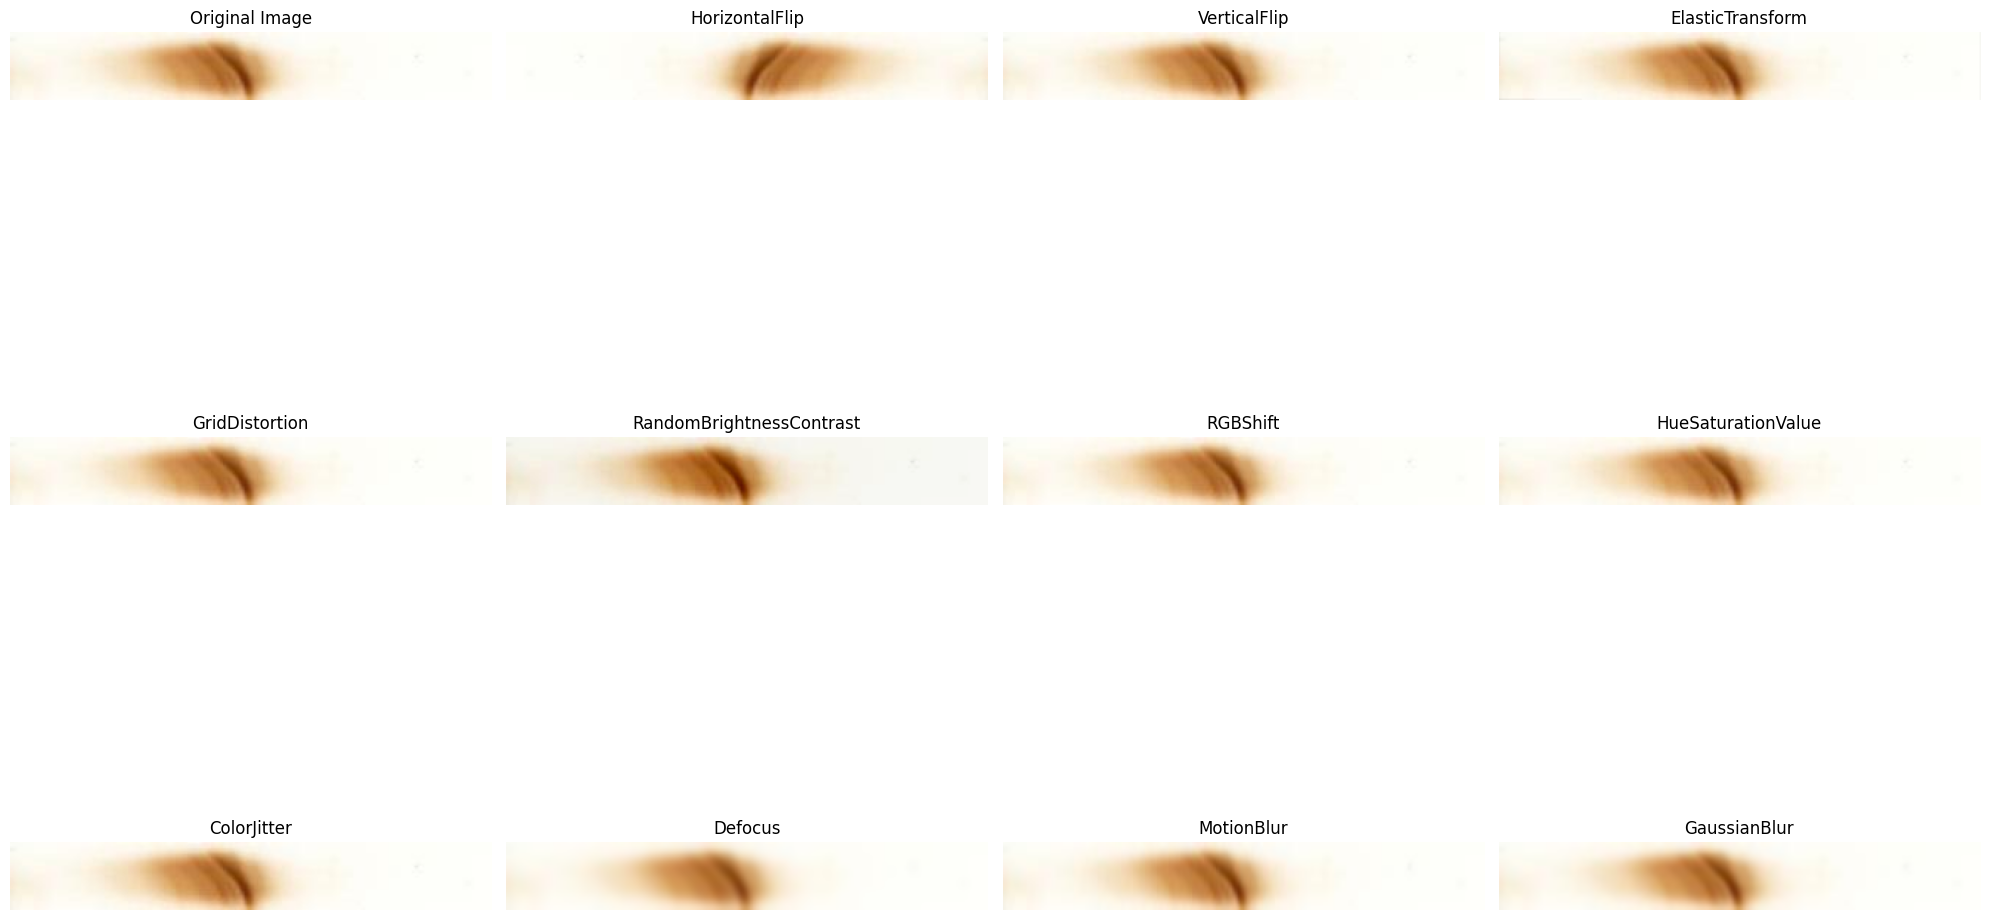

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2 # Import ToTensorV2

# 🔧 Définir les transformations d'augmentation
transform = A.Compose([

                # Geometric augmentations (preserve alignment between image and mask)
    A.HorizontalFlip(p=0.5),  # Flip horizontally
    A.VerticalFlip(p=0.5),    # Flip vertically
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=30, border_mode=0, p=0.5),  # Random shifts, scaling, and rotation
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),  # Elastic distortions
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),  # Grid warping
    A.OpticalDistortion(distort_limit=0.2, shift_limit=0.2, p=0.5),  # Lens-like distortions

    # Color augmentations (preserve pixel values for segmentation masks)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # Adjust brightness and contrast
    A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.3),  # Shift RGB channels slightly
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3),  # Adjust hue, saturation, and value
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),  # Random color jittering

    # Blur augmentations
    A.Defocus(radius=(3, 5), p=0.3),  # Simulate defocus blur
    A.MotionBlur(blur_limit=(3, 5), p=0.3),  # Add motion blur
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),  # Apply Gaussian blur

    # Random cropping for patch-level segmentation
    # Added pad_if_needed=True to handle images smaller than the crop size
    A.RandomCrop(width=128, height=128, p=1.0, pad_if_needed=True), # Ensure crop size matches training requirements

    # Normalize image (mean, std, based on pre-trained networks like ImageNet)
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], p=1.0),

    # Convert to tensor
    ToTensorV2()
])

# Load a sample image
img_path = '/content/drive/MyDrive/Data_paper1/AF/150.jpg'
image = Image.open(img_path).convert("RGB")

# Convert to numpy array for augmentation
image_np = np.array(image)

# Apply the entire augmentation pipeline
# This will now pad the image if it's smaller than 128x128 before cropping
augmented = transform(image=image_np)
augmented_image = augmented['image'] # This will be a tensor

# The result of the augmentation is a tensor after ToTensorV2.
# For visualization, you'll need to convert it back to a numpy array and unnormalize it.
# However, the goal was to visualize each *individual* augmentation.
# To achieve that, you need to apply each augmentation one by one, but handle the crop
# or remove it from the visualization loop if the original image is too small.

# Let's adjust the visualization loop to apply individual transforms and handle the crop.
# We will skip the RandomCrop and ToTensorV2 transforms for this visualization loop,
# as they change the image dimensions or type in a way that makes direct comparison
# to the original challenging in a simple grid like this.

# Note: This visualization loop will apply individual transforms *without* the padding
# added above for the main pipeline. If an individual transform like ElasticTransform
# requires padding or an image larger than its current size, it might still fail or
# produce unexpected results if not handled specifically. The RandomCrop is explicitly
# excluded from this viz pipeline.

transform_for_viz = A.Compose([
    # Geometric augmentations (preserve alignment between image and mask)
    A.HorizontalFlip(p=0.5),  # Flip horizontally
    A.VerticalFlip(p=0.5),    # Flip vertically
    # Random shifts, scaling, and rotation
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),  # Elastic distortions
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),  # Grid warping

    # Color augmentations (preserve pixel values for segmentation masks)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # Adjust brightness and contrast
    A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.3),  # Shift RGB channels slightly
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3),  # Adjust hue, saturation, and value
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),  # Random color jittering

    # Blur augmentations
    A.Defocus(radius=(3, 5), p=0.3),  # Simulate defocus blur
    A.MotionBlur(blur_limit=(3, 5), p=0.3),  # Add motion blur
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),  # Apply Gaussian blur
    # Exclude RandomCrop and ToTensorV2 for this visualization
])


augmented_images = []
# Apply and collect results from individual transforms (excluding crop and ToTensorV2)
for individual_transform in transform_for_viz.transforms:
    try:
        # Apply the individual transform. Keeping original p means some transforms might not apply.
        augmented_result = individual_transform(image=image_np)
        augmented_images.append(augmented_result['image'])
    except Exception as e:
        print(f"Could not apply transform {type(individual_transform).__name__}: {e}")
        # Append original image or a placeholder if augmentation fails
        # Appending the original image allows the loop to continue and display something
        augmented_images.append(image_np)


# Plot original and augmented images
# Determine the number of images to display (original + augmented that were successfully applied)
num_images_to_display = 1 + len(augmented_images)
cols = 4
rows = (num_images_to_display + cols - 1) // cols # Calculate rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5)) # Adjust figsize based on grid

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Display each augmented image that was successfully generated
for i, augmented_img in enumerate(augmented_images, start=1):
    if i < len(axes): # Ensure we don't go out of bounds
        # Ensure the image data type is suitable for imshow (e.g., uint8)
        if isinstance(augmented_img, np.ndarray) and augmented_img.dtype in [np.float32, np.float64]:
             # If it's a float, assume it's in the 0-1 range and convert to uint8 0-255
             # This might not be correct after normalization, but for pre-normalization
             # visualization, it's a common issue. For post-normalization tensors,
             # you would need to unnormalize before converting to displayable format.
             # Given the viz loop excludes Normalize/ToTensorV2, this check is mainly
             # for intermediate float results from some transforms if they occur.
            display_img = (augmented_img * 255).astype(np.uint8)
        else:
            display_img = augmented_img

        axes[i].imshow(display_img)
        # Get the name of the transform that generated this image (if successful)
        transform_name = type(transform_for_viz.transforms[i-1]).__name__ if i-1 < len(transform_for_viz.transforms) else "Augmented"
        axes[i].set_title(f"{transform_name}")
        axes[i].axis('off')

# Hide any unused subplots
for j in range(num_images_to_display, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

<ipython-input-9-5fc61e6606c3>:27: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  ("ElasticTransform", A.Compose([A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),


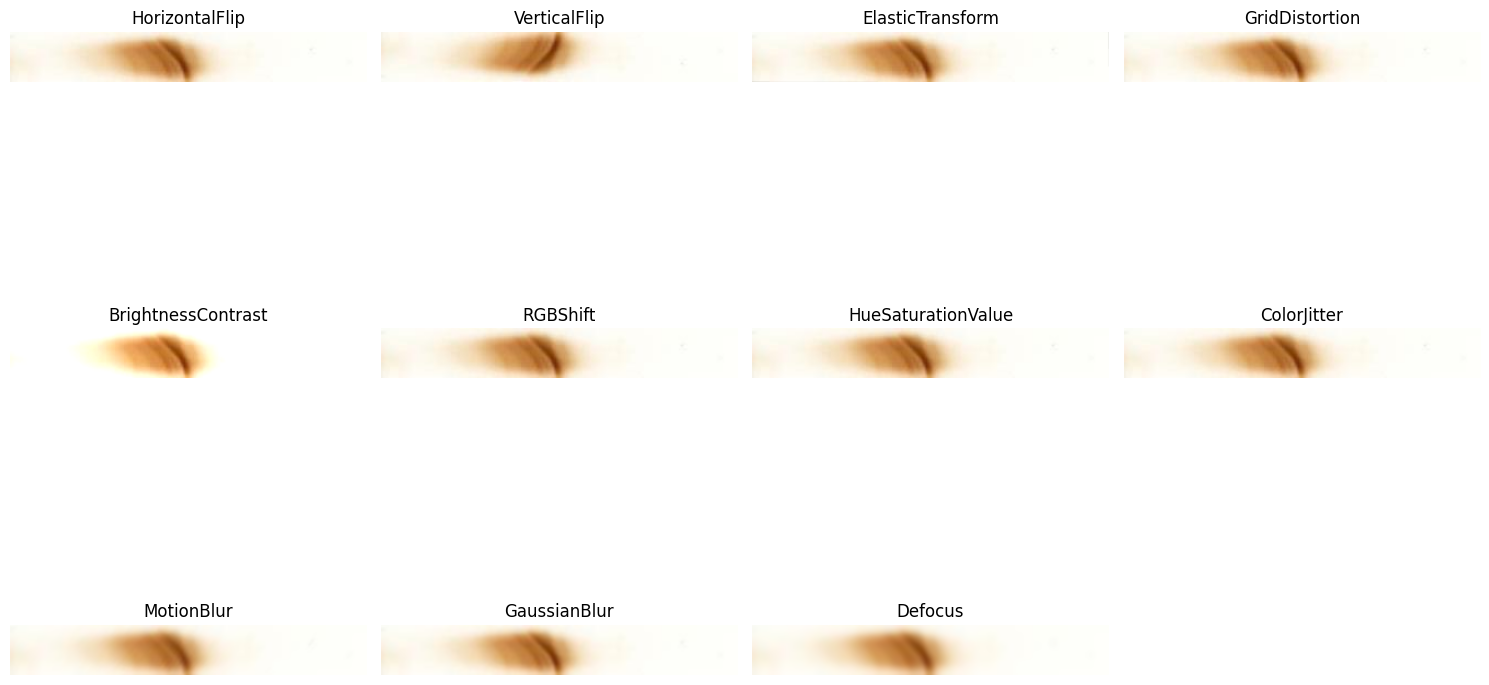

In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import matplotlib.pyplot as plt
from uuid import uuid4

# Dossier de sortie
OUTPUT_DIR = "aug_test_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Charger une image
image_path = "/content/drive/MyDrive/Data_paper1/AF/150.jpg"  # Remplace ce chemin
image = cv2.imread(image_path)
if image is None:
    raise ValueError(f"Erreur de lecture de l'image : {image_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
H, W, _ = image.shape  # Garder la taille d'origine

# Transformations individuelles (sans redimensionnement)
def get_individual_transforms():
    return [
        ("HorizontalFlip", A.Compose([A.HorizontalFlip(p=0.5), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("VerticalFlip", A.Compose([A.VerticalFlip(p=0.5), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("ElasticTransform", A.Compose([A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("GridDistortion", A.Compose([A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("BrightnessContrast", A.Compose([A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("RGBShift", A.Compose([A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.3), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("HueSaturationValue", A.Compose([A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("ColorJitter", A.Compose([A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("MotionBlur", A.Compose([A.MotionBlur(blur_limit=(3, 5), p=1.0), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("GaussianBlur", A.Compose([A.GaussianBlur(blur_limit=(3, 5), p=1.0), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
        ("Defocus", A.Compose([A.Defocus(radius=(3, 5), p=0.3), A.Normalize(mean=(0.5,)*3, std=(0.5,)*3), ToTensorV2()])),
    ]

# Appliquer et afficher les augmentations
transforms = get_individual_transforms()

plt.figure(figsize=(15, 10))
for i, (name, transform) in enumerate(transforms):
    augmented = transform(image=image)
    tensor_image = augmented["image"]

    # Convertir vers image affichable
    img_np = tensor_image.permute(1, 2, 0).cpu().numpy()
    img_np = ((img_np * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)

    # Afficher l'image
    plt.subplot(3, 4, i + 1)
    plt.imshow(img_np)
    plt.title(name)
    plt.axis('off')

    # Sauvegarder
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    save_path = os.path.join(OUTPUT_DIR, f"{name}_{uuid4().hex[:8]}.jpg")
    cv2.imwrite(save_path, img_bgr)

plt.tight_layout()
plt.show()
